# Imports ....

In [18]:
import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Set the device ....

In [19]:
# ===============================================================
# Device
# ===============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


# Set the hyper parameters ...

In [30]:
# ===============================================================
# Hyperparameters
# ===============================================================
DATA_PATH = "10_DATA_TRPCAGE.npy"
BATCH_SIZE = 4096
DATA_DIM = 38
HIDDEN_DIM = 256
EPOCHS = 1000
LR = 5e-5
DROPOUT = 0.2

SAVE_DIR   = "Diffusion/unet_rs/models"
SAMPLE_DIR = "Diffusion/unet_rs/samples"
LOSS_FILE  = "Diffusion/unet_rs/loss.txt"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

# The Forward process of diffusion ...

In [21]:
# ===============================================================
# Diffusion Schedule
# ===============================================================
T = 1000
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise):
    a_bar = alpha_bar[t].unsqueeze(1)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

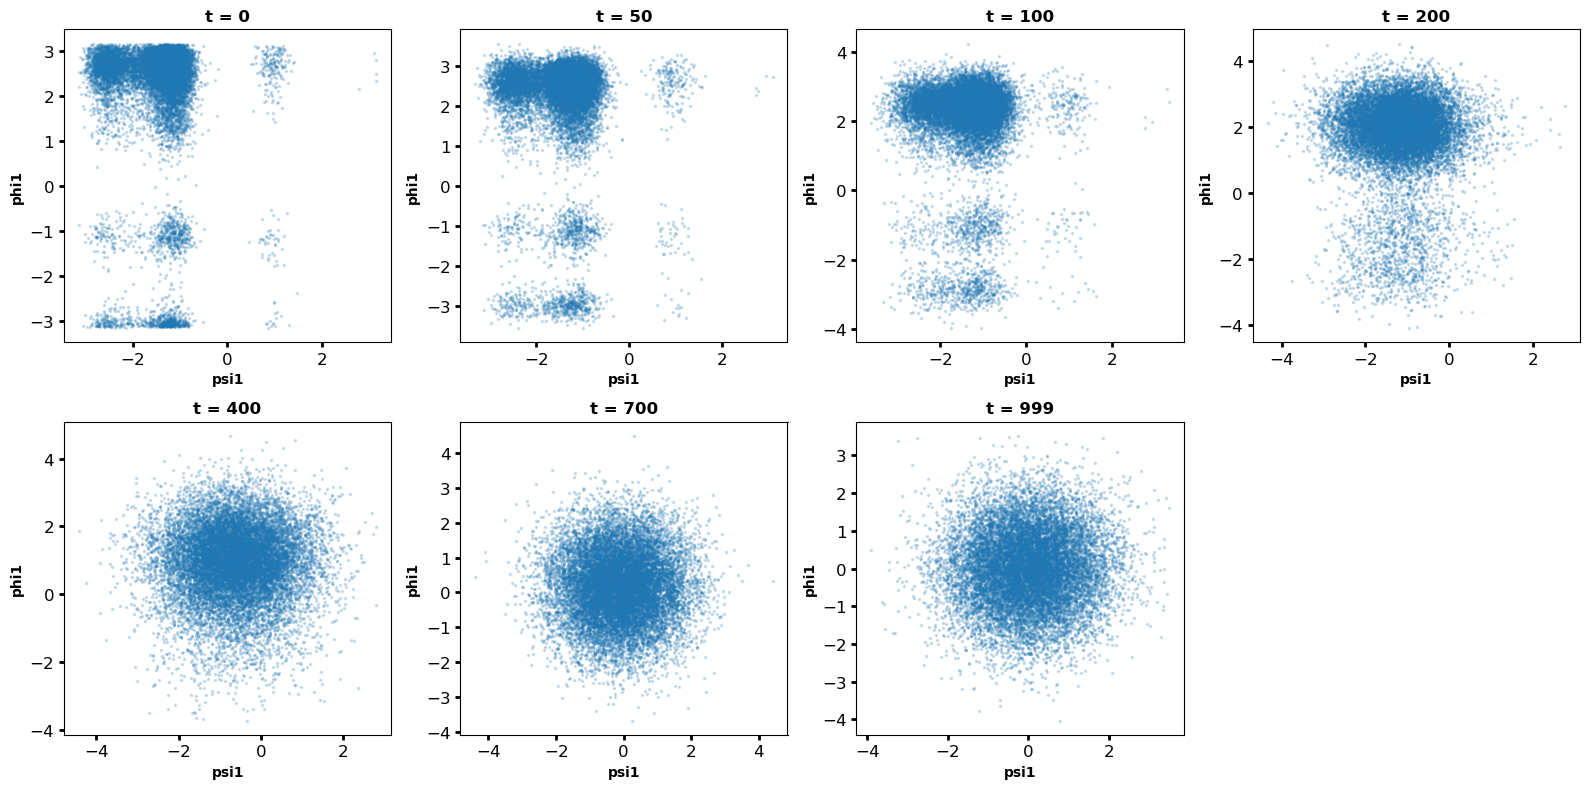

In [44]:

X0 = torch.tensor(np.load(DATA_PATH), dtype=torch.float32).to(device)

idx = torch.randperm(X0.shape[0])[:15000]
X0 = X0[idx]

# ===============================================================
# Timesteps
# ===============================================================
timesteps = [0, 50, 100, 200, 400, 700, 999]

# ===============================================================
# Plot
# ===============================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, t in enumerate(timesteps):
    t_tensor = torch.tensor([t], device=device)
    noise = torch.randn_like(X0)
    Xt = q_sample(X0, t_tensor, noise)

    psi = Xt[:, 0].cpu().numpy()
    phi = Xt[:, 1].cpu().numpy()

    ax = axes[i]
    ax.scatter(psi, phi, alpha=0.2, s=2)

    ax.set_title(f"t = {t}", fontweight='bold')
    ax.set_xlabel("psi1", fontweight='bold')
    ax.set_ylabel("phi1", fontweight='bold')

    ax.tick_params(axis='both', labelsize=12, width=2)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig("Forward_trpcage_diffusion.png")
plt.show()

# Lets learn the reverse process by creating the model ,.......

# Lets add time embedding ...

In [23]:
# ===============================================================
# Time Embedding
# ===============================================================
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU()
        )

    def forward(self, t):
        return self.net(t.unsqueeze(-1).float())

# Lets create the neural network which predicts the added noise at given time step t

In [24]:
# ===============================================================
# Model  Diffusion MLP (No residuals)
# ===============================================================
class DiffusionMLP(nn.Module):
    def __init__(self, data_dim, hidden_dim, dropout):
        super().__init__()
        self.time_embed = TimeEmbedding(hidden_dim)

        self.net = nn.Sequential(
            nn.Linear(data_dim + hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        h = torch.cat([x, t_emb], dim=-1)
        return self.net(h)

# Lets define the diffusion loss

In [25]:
# ===============================================================
# Diffusion Loss
# ===============================================================
def diffusion_loss(model, x0):
    bsz = x0.size(0)
    t = torch.randint(0, T, (bsz,), device=device)
    noise = torch.randn_like(x0)

    xt = q_sample(x0, t, noise)
    pred_noise = model(xt, t.float() / T)

    return F.mse_loss(pred_noise, noise)

# Load the data for training ......

In [27]:
# ===============================================================
# Load Data
# ===============================================================
data = np.load(DATA_PATH).astype(np.float32)
N = data.shape[0]
print("Loaded:", data.shape)

Loaded: (50000, 38)


# Initialize the model and optimizer .....

In [28]:
model = DiffusionMLP(DATA_DIM, HIDDEN_DIM, DROPOUT).to(device)


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Training phase ....

In [31]:
# ===============================================================
# Training
# ===============================================================
print("=== TRAINING STARTED ===")
loss_log = []
start = time.time()

for epoch in range(1, EPOCHS + 1):
    perm = torch.randperm(N)
    epoch_loss = 0
    nb = 0

    for i in range(0, N, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        x1 = torch.tensor(data[idx], device=device)

        loss = diffusion_loss(model, x1)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        nb += 1

    avg_loss = epoch_loss / nb
    loss_log.append(avg_loss)
    print(f"Epoch {epoch:04d} | Loss: {avg_loss:.6f}",flush=True)

    np.savetxt(LOSS_FILE, np.array(loss_log))

    if epoch % 100 == 0:
        path = os.path.join(SAVE_DIR, f"model_epoch_{epoch}.pt")
        torch.save(model.state_dict(), path)

print("Training finished in %.2f minutes" % ((time.time()-start)/60))


=== TRAINING STARTED ===
Epoch 0001 | Loss: 0.675927
Epoch 0002 | Loss: 0.659921
Epoch 0003 | Loss: 0.648659
Epoch 0004 | Loss: 0.636261
Epoch 0005 | Loss: 0.628337
Epoch 0006 | Loss: 0.615638
Epoch 0007 | Loss: 0.608483
Epoch 0008 | Loss: 0.601844
Epoch 0009 | Loss: 0.592956
Epoch 0010 | Loss: 0.585059
Epoch 0011 | Loss: 0.576577
Epoch 0012 | Loss: 0.571143
Epoch 0013 | Loss: 0.566159
Epoch 0014 | Loss: 0.558017
Epoch 0015 | Loss: 0.554929
Epoch 0016 | Loss: 0.551518
Epoch 0017 | Loss: 0.546043
Epoch 0018 | Loss: 0.544523
Epoch 0019 | Loss: 0.536250
Epoch 0020 | Loss: 0.529797
Epoch 0021 | Loss: 0.528977
Epoch 0022 | Loss: 0.525319
Epoch 0023 | Loss: 0.522598
Epoch 0024 | Loss: 0.518692
Epoch 0025 | Loss: 0.518408
Epoch 0026 | Loss: 0.514210
Epoch 0027 | Loss: 0.509607
Epoch 0028 | Loss: 0.507042
Epoch 0029 | Loss: 0.504867
Epoch 0030 | Loss: 0.503117
Epoch 0031 | Loss: 0.498883
Epoch 0032 | Loss: 0.499068
Epoch 0033 | Loss: 0.493863
Epoch 0034 | Loss: 0.498081
Epoch 0035 | Loss: 0.49

Epoch 0293 | Loss: 0.399008
Epoch 0294 | Loss: 0.399358
Epoch 0295 | Loss: 0.397259
Epoch 0296 | Loss: 0.399014
Epoch 0297 | Loss: 0.397676
Epoch 0298 | Loss: 0.397643
Epoch 0299 | Loss: 0.396519
Epoch 0300 | Loss: 0.397878
Epoch 0301 | Loss: 0.396398
Epoch 0302 | Loss: 0.397517
Epoch 0303 | Loss: 0.398645
Epoch 0304 | Loss: 0.397789
Epoch 0305 | Loss: 0.398220
Epoch 0306 | Loss: 0.394474
Epoch 0307 | Loss: 0.394512
Epoch 0308 | Loss: 0.396555
Epoch 0309 | Loss: 0.396709
Epoch 0310 | Loss: 0.397004
Epoch 0311 | Loss: 0.398928
Epoch 0312 | Loss: 0.395708
Epoch 0313 | Loss: 0.396375
Epoch 0314 | Loss: 0.394545
Epoch 0315 | Loss: 0.395861
Epoch 0316 | Loss: 0.396936
Epoch 0317 | Loss: 0.396067
Epoch 0318 | Loss: 0.395194
Epoch 0319 | Loss: 0.394636
Epoch 0320 | Loss: 0.395952
Epoch 0321 | Loss: 0.396299
Epoch 0322 | Loss: 0.394498
Epoch 0323 | Loss: 0.394871
Epoch 0324 | Loss: 0.394616
Epoch 0325 | Loss: 0.396798
Epoch 0326 | Loss: 0.394830
Epoch 0327 | Loss: 0.395570
Epoch 0328 | Loss: 0

Epoch 0586 | Loss: 0.383542
Epoch 0587 | Loss: 0.381549
Epoch 0588 | Loss: 0.380909
Epoch 0589 | Loss: 0.381504
Epoch 0590 | Loss: 0.380111
Epoch 0591 | Loss: 0.378625
Epoch 0592 | Loss: 0.378845
Epoch 0593 | Loss: 0.379284
Epoch 0594 | Loss: 0.380964
Epoch 0595 | Loss: 0.380270
Epoch 0596 | Loss: 0.380345
Epoch 0597 | Loss: 0.379115
Epoch 0598 | Loss: 0.377368
Epoch 0599 | Loss: 0.382040
Epoch 0600 | Loss: 0.381321
Epoch 0601 | Loss: 0.379515
Epoch 0602 | Loss: 0.381535
Epoch 0603 | Loss: 0.382621
Epoch 0604 | Loss: 0.381752
Epoch 0605 | Loss: 0.378476
Epoch 0606 | Loss: 0.378381
Epoch 0607 | Loss: 0.379992
Epoch 0608 | Loss: 0.379912
Epoch 0609 | Loss: 0.379278
Epoch 0610 | Loss: 0.379083
Epoch 0611 | Loss: 0.380761
Epoch 0612 | Loss: 0.381494
Epoch 0613 | Loss: 0.377980
Epoch 0614 | Loss: 0.378082
Epoch 0615 | Loss: 0.380179
Epoch 0616 | Loss: 0.379512
Epoch 0617 | Loss: 0.378122
Epoch 0618 | Loss: 0.379217
Epoch 0619 | Loss: 0.378998
Epoch 0620 | Loss: 0.380398
Epoch 0621 | Loss: 0

Epoch 0879 | Loss: 0.370042
Epoch 0880 | Loss: 0.371329
Epoch 0881 | Loss: 0.372140
Epoch 0882 | Loss: 0.371643
Epoch 0883 | Loss: 0.374753
Epoch 0884 | Loss: 0.373615
Epoch 0885 | Loss: 0.372408
Epoch 0886 | Loss: 0.372480
Epoch 0887 | Loss: 0.373873
Epoch 0888 | Loss: 0.372878
Epoch 0889 | Loss: 0.374075
Epoch 0890 | Loss: 0.371711
Epoch 0891 | Loss: 0.371488
Epoch 0892 | Loss: 0.372570
Epoch 0893 | Loss: 0.370642
Epoch 0894 | Loss: 0.368144
Epoch 0895 | Loss: 0.373396
Epoch 0896 | Loss: 0.372606
Epoch 0897 | Loss: 0.370031
Epoch 0898 | Loss: 0.371917
Epoch 0899 | Loss: 0.371700
Epoch 0900 | Loss: 0.372255
Epoch 0901 | Loss: 0.370327
Epoch 0902 | Loss: 0.370550
Epoch 0903 | Loss: 0.372284
Epoch 0904 | Loss: 0.371424
Epoch 0905 | Loss: 0.368378
Epoch 0906 | Loss: 0.369436
Epoch 0907 | Loss: 0.369096
Epoch 0908 | Loss: 0.371812
Epoch 0909 | Loss: 0.370423
Epoch 0910 | Loss: 0.370456
Epoch 0911 | Loss: 0.370114
Epoch 0912 | Loss: 0.372145
Epoch 0913 | Loss: 0.372114
Epoch 0914 | Loss: 0

# Sampling Phase .....

In [45]:
# ===============================================================
# Reverse Diffusion Sampler
# ===============================================================
@torch.no_grad()
def sample_diffusion(model, n_samples=1024):
    model.eval()
    x = torch.randn(n_samples, DATA_DIM, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t/T, device=device)
        beta = betas[t]
        alpha = alphas[t]
        a_bar = alpha_bar[t]

        eps = model(x, t_batch)

        mean = (1/torch.sqrt(alpha)) * (x - beta/torch.sqrt(1 - a_bar) * eps)

        if t > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    return x.cpu().numpy()

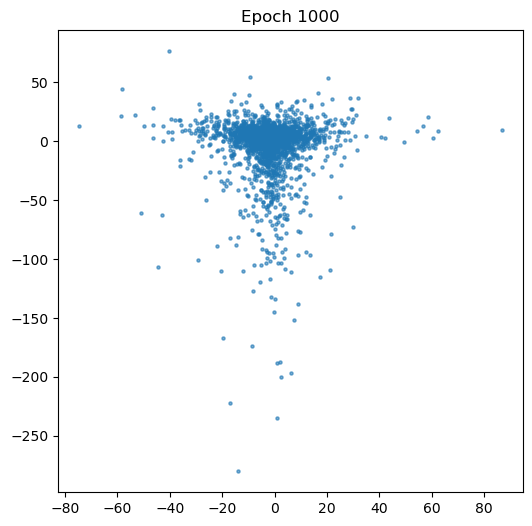

Training finished in 12.65 minutes


In [46]:


samples = sample_diffusion(model, 5000)
np.save(os.path.join(SAMPLE_DIR, f"samples_{epoch}.npy"), samples)

plt.figure(figsize=(6,6))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.6)
plt.title(f"Epoch {epoch}")
plt.savefig(os.path.join(SAMPLE_DIR, f"samples_{epoch}.png"))
plt.show()

print("Training finished in %.2f minutes" % ((time.time()-start)/60))

# Sample from the saved model ...

In [47]:

MODEL_PATH ="Diffusion/unet_rs/models/model_epoch_50000.pt"

In [48]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Loaded model:",flush=True)

Loaded model:


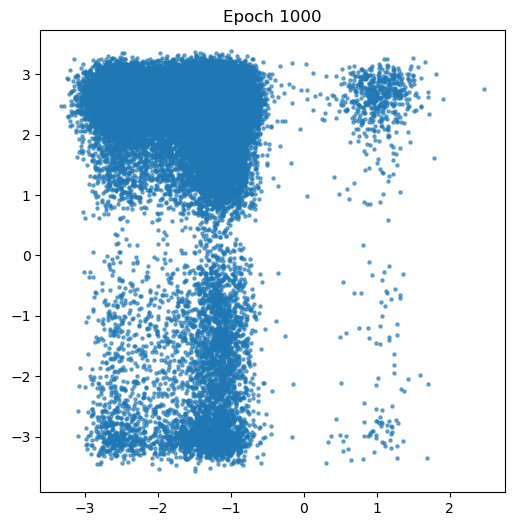

In [49]:


samples = sample_diffusion(model, 50000)
np.save(os.path.join(SAMPLE_DIR, f"samples_{epoch}.npy"), samples)

plt.figure(figsize=(6,6))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.6)
plt.title(f"Epoch 50000")
plt.savefig(os.path.join(SAMPLE_DIR, f"samples_{epoch}.png"))
plt.show()



In [52]:
timesteps = [0, 50, 100, 200, 400, 700, 999]
save_steps = set(timesteps)   

In [53]:
def sample_diffusion_trajectory(model, n_samples):
    model.eval()
    
    Xt = torch.randn(n_samples, DATA_DIM).to(device)
    
    trajectory = {}

    for t in reversed(range(T)):   
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)

        eps_theta = model(Xt, t_tensor)

        Xt = (1 / torch.sqrt(alphas[t])) * (
            Xt - (1 - alphas[t]) / torch.sqrt(1 - alpha_bar[t]) * eps_theta
        )

        if t > 0:
            Xt += torch.sqrt(betas[t]) * torch.randn_like(Xt)

        if t in save_steps:
            trajectory[t] = Xt.detach().cpu().numpy()

    return trajectory

In [ ]:
trajectory = sample_diffusion_trajectory(model, 50000)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, t in enumerate(sorted(timesteps, reverse=True)):  
    samples = trajectory[t]

    psi = samples[:, 0]
    phi = samples[:, 1]

    ax = axes[i]
    ax.scatter(psi, phi, s=2, alpha=0.2)

    ax.set_title(f"t = {t}", fontweight='bold')
    ax.set_xlabel("psi1", fontweight='bold')
    ax.set_ylabel("phi1", fontweight='bold')
    ax.tick_params(width=2)

# remove extra subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig("reverse_diffusion_fixed.png")
plt.show()